# N00 — Measurement Validation

**Research question.** Are the metrics and statistical procedures used in every later notebook implemented correctly?

**Purpose.** This notebook validates the measuring tools before they are applied to final patient-level analyses. The final protocol is a **post-exploratory freeze**, not a preregistration.

## Reader Guide

**Pipeline role:** Validates the measurement layer before any patient-level analysis.

**Inputs:** Synthetic test cases only. **Produces:** the shared measurement module, the frozen post-exploratory protocol, validation tables and figures, an acceptance certificate, and an output manifest.

**Continue only when:** `n00_status.json` records an accepted run.

## 0. Notebook contract

This notebook uses synthetic data only. It creates a shared Python module, tests that module against independent references and hand-calculated cases, records the final protocol, and stops with an error if any required test fails.

In [1]:
from pathlib import Path

import hashlib, json, platform, sys, shutil

from datetime import datetime, timezone



import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import scipy

from scipy.stats import binomtest

import sklearn

from sklearn.metrics import (

    accuracy_score, balanced_accuracy_score, cohen_kappa_score,

    f1_score, log_loss, mean_absolute_error, mean_squared_error,

    roc_auc_score, average_precision_score,

)



IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:

    from google.colab import drive

    drive.mount("/content/drive", force_remount=False)



FINAL_ROOT = Path("/content/drive/MyDrive/MasterThesis/Final Pipeline")

STAGE = "N00"

SRC = FINAL_ROOT / "src"

TABLES = FINAL_ROOT / "tables" / STAGE

FIGURES = FINAL_ROOT / "figures" / STAGE

RESULTS = FINAL_ROOT / "results" / STAGE

LOGS = FINAL_ROOT / "logs" / STAGE

CONFIGS = FINAL_ROOT / "configs"

CERTIFICATES = FINAL_ROOT / "certificates"

MANIFESTS = FINAL_ROOT / "manifests"



for folder in (SRC, TABLES, FIGURES, RESULTS, LOGS, CONFIGS, CERTIFICATES, MANIFESTS):

    folder.mkdir(parents=True, exist_ok=True)



RANDOM_SEED = 20260800

RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")

print("FINAL_ROOT:", FINAL_ROOT)

print("RUN_ID:", RUN_ID)

Mounted at /content/drive
FINAL_ROOT: /content/drive/MyDrive/MasterThesis/Final Pipeline
RUN_ID: 20260805T074435Z


## 1. Create the shared measurement module

In [2]:
MODULE_SOURCE = '\n"""Validated measurement tools for the final thesis pipeline.\n\nThis module is created and tested by N00. Later notebooks must import these\nfunctions rather than copy local variants.\n"""\nfrom __future__ import annotations\n\nfrom dataclasses import dataclass\nfrom typing import Callable, Iterable, Sequence\n\nimport numpy as np\nfrom sklearn.metrics import confusion_matrix\n\n\ndef _as_1d(values, name: str, dtype=None) -> np.ndarray:\n    array = np.asarray(values, dtype=dtype)\n    if array.ndim != 1:\n        raise ValueError(f"{name} must be one-dimensional.")\n    if array.size == 0:\n        raise ValueError(f"{name} must not be empty.")\n    if not np.all(np.isfinite(array)):\n        raise ValueError(f"{name} contains non-finite values.")\n    return array\n\n\ndef validate_probabilities(probabilities, n_classes: int | None = None) -> np.ndarray:\n    p = np.asarray(probabilities, dtype=float)\n    if p.ndim != 2 or p.shape[0] == 0 or p.shape[1] < 2:\n        raise ValueError("probabilities must have shape (n_samples, n_classes).")\n    if not np.all(np.isfinite(p)):\n        raise ValueError("probabilities contain non-finite values.")\n    if np.any(p < 0):\n        raise ValueError("probabilities contain negative values.")\n    row_sums = p.sum(axis=1)\n    if not np.allclose(row_sums, 1.0, atol=1e-7):\n        raise ValueError("probability rows must sum to one.")\n    if n_classes is not None and p.shape[1] != int(n_classes):\n        raise ValueError(f"expected {n_classes} classes, found {p.shape[1]}.")\n    return p\n\n\ndef manual_quadratic_weighted_kappa(\n    y_true,\n    y_pred,\n    labels: Sequence[int] = (0, 1, 2, 3, 4),\n    sample_weight=None,\n) -> float:\n    """Quadratic weighted kappa from the observed and expected matrices."""\n    yt = _as_1d(y_true, "y_true")\n    yp = _as_1d(y_pred, "y_pred")\n    if yt.shape != yp.shape:\n        raise ValueError("y_true and y_pred must have equal length.")\n    labels = np.asarray(labels)\n    if labels.ndim != 1 or labels.size < 2:\n        raise ValueError("labels must contain at least two ordered classes.")\n    weights = None\n    if sample_weight is not None:\n        weights = _as_1d(sample_weight, "sample_weight", dtype=float)\n        if weights.shape != yt.shape or np.any(weights < 0):\n            raise ValueError("sample_weight must be non-negative and aligned.")\n    observed = confusion_matrix(yt, yp, labels=labels, sample_weight=weights).astype(float)\n    total = observed.sum()\n    if total <= 0:\n        raise ValueError("total sample weight must be positive.")\n    true_hist = observed.sum(axis=1)\n    pred_hist = observed.sum(axis=0)\n    expected = np.outer(true_hist, pred_hist) / total\n    k = len(labels)\n    idx = np.arange(k, dtype=float)\n    disagreement = (idx[:, None] - idx[None, :]) ** 2 / float((k - 1) ** 2)\n    observed_disagreement = float((disagreement * observed).sum() / total)\n    expected_disagreement = float((disagreement * expected).sum() / total)\n    if expected_disagreement <= np.finfo(float).eps:\n        return 1.0 if observed_disagreement <= np.finfo(float).eps else float("nan")\n    return float(1.0 - observed_disagreement / expected_disagreement)\n\n\ndef multiclass_brier_score(y_true, probabilities, labels=None) -> float:\n    p = validate_probabilities(probabilities)\n    yt = _as_1d(y_true, "y_true")\n    if len(yt) != len(p):\n        raise ValueError("y_true and probabilities must be aligned.")\n    if labels is None:\n        labels = np.arange(p.shape[1])\n    labels = np.asarray(labels)\n    if len(labels) != p.shape[1]:\n        raise ValueError("labels must match probability columns.")\n    lookup = {label: i for i, label in enumerate(labels.tolist())}\n    try:\n        indices = np.array([lookup[value] for value in yt], dtype=int)\n    except KeyError as exc:\n        raise ValueError(f"unknown class in y_true: {exc}") from exc\n    one_hot = np.eye(p.shape[1], dtype=float)[indices]\n    return float(np.mean(np.sum((p - one_hot) ** 2, axis=1)))\n\n\ndef top_label_ece(y_true, probabilities, n_bins: int = 15) -> float:\n    """Equal-width top-label expected calibration error on [0, 1]."""\n    p = validate_probabilities(probabilities)\n    yt = _as_1d(y_true, "y_true")\n    if len(yt) != len(p):\n        raise ValueError("y_true and probabilities must be aligned.")\n    if n_bins < 2:\n        raise ValueError("n_bins must be at least two.")\n    pred = p.argmax(axis=1)\n    conf = p.max(axis=1)\n    correct = (pred == yt).astype(float)\n    edges = np.linspace(0.0, 1.0, n_bins + 1)\n    bins = np.digitize(conf, edges[1:-1], right=True)\n    ece = 0.0\n    for bin_index in range(n_bins):\n        mask = bins == bin_index\n        if mask.any():\n            ece += mask.mean() * abs(correct[mask].mean() - conf[mask].mean())\n    return float(ece)\n\n\ndef risk_coverage_curve(losses, confidence, tie_aware: bool = True):\n    """Return admissible coverage and selective risk.\n\n    When tie_aware=True, a threshold may retain an entire confidence group only.\n    The curve includes (coverage=0, risk=0) as the integration origin.\n    """\n    loss = _as_1d(losses, "losses", dtype=float)\n    conf = _as_1d(confidence, "confidence", dtype=float)\n    if loss.shape != conf.shape:\n        raise ValueError("losses and confidence must have equal length.")\n    if np.any(loss < 0):\n        raise ValueError("losses must be non-negative.")\n    order = np.argsort(-conf, kind="mergesort")\n    ordered_loss = loss[order]\n    ordered_conf = conf[order]\n    cumulative_risk = np.cumsum(ordered_loss) / np.arange(1, len(loss) + 1)\n    coverage = np.arange(1, len(loss) + 1, dtype=float) / len(loss)\n    if tie_aware:\n        keep = np.r_[ordered_conf[:-1] != ordered_conf[1:], True]\n        coverage = coverage[keep]\n        cumulative_risk = cumulative_risk[keep]\n    coverage = np.r_[0.0, coverage]\n    cumulative_risk = np.r_[0.0, cumulative_risk]\n    return coverage, cumulative_risk\n\n\ndef aurc(losses, confidence, tie_aware: bool = True) -> float:\n    """Empirical area under the right-continuous risk-coverage step curve."""\n    coverage, risk = risk_coverage_curve(losses, confidence, tie_aware=tie_aware)\n    increments = np.diff(coverage)\n    return float(np.sum(risk[1:] * increments))\n\n\ndef risk_at_coverage(losses, confidence, target_coverage: float, tie_aware: bool = True):\n    if not (0 < target_coverage <= 1):\n        raise ValueError("target_coverage must be in (0, 1].")\n    coverage, risk = risk_coverage_curve(losses, confidence, tie_aware=tie_aware)\n    valid = np.flatnonzero(coverage >= target_coverage)\n    if len(valid) == 0:\n        return float(risk[-1]), float(coverage[-1])\n    index = int(valid[0])\n    return float(risk[index]), float(coverage[index])\n\n\ndef participant_bootstrap_indices(participant_ids, n_resamples: int, seed: int):\n    ids = _as_1d(participant_ids, "participant_ids")\n    if n_resamples < 1:\n        raise ValueError("n_resamples must be positive.")\n    unique_ids = np.unique(ids)\n    rows_by_id = {pid: np.flatnonzero(ids == pid) for pid in unique_ids}\n    rng = np.random.default_rng(seed)\n    for _ in range(n_resamples):\n        sampled_ids = rng.choice(unique_ids, size=len(unique_ids), replace=True)\n        yield np.concatenate([rows_by_id[pid] for pid in sampled_ids])\n\n\ndef paired_participant_bootstrap(\n    participant_ids,\n    statistic: Callable[[np.ndarray], float],\n    n_resamples: int = 2000,\n    seed: int = 0,\n    confidence_level: float = 0.95,\n):\n    values = np.array(\n        [statistic(index) for index in participant_bootstrap_indices(participant_ids, n_resamples, seed)],\n        dtype=float,\n    )\n    values = values[np.isfinite(values)]\n    if len(values) < max(100, n_resamples // 2):\n        raise RuntimeError("too few finite bootstrap estimates.")\n    alpha = 1.0 - confidence_level\n    lower, upper = np.quantile(values, [alpha / 2, 1 - alpha / 2])\n    return {\n        "lower": float(lower),\n        "upper": float(upper),\n        "mean": float(values.mean()),\n        "standard_error": float(values.std(ddof=1)),\n        "values": values,\n    }\n'

MODULE_PATH = SRC / "measurement_tools.py"

MODULE_PATH.write_text(MODULE_SOURCE, encoding="utf-8")

if str(FINAL_ROOT) not in sys.path:

    sys.path.insert(0, str(FINAL_ROOT))



from src.measurement_tools import (

    aurc, manual_quadratic_weighted_kappa, multiclass_brier_score,

    paired_participant_bootstrap, participant_bootstrap_indices,

    risk_at_coverage, risk_coverage_curve, top_label_ece,

    validate_probabilities,

)

print("Shared module:", MODULE_PATH)

Shared module: /content/drive/MyDrive/MasterThesis/Final Pipeline/src/measurement_tools.py


## 2. Environment

In [3]:
try:

    import torch

    torch_version = torch.__version__

    cuda_version = torch.version.cuda

    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none"

except ImportError:

    torch_version, cuda_version, gpu_name = "not installed", "n/a", "n/a"



environment = {

    "python": sys.version.split()[0],

    "platform": platform.platform(),

    "numpy": np.__version__,

    "pandas": pd.__version__,

    "scipy": scipy.__version__,

    "sklearn": sklearn.__version__,

    "torch": torch_version,

    "cuda": cuda_version,

    "gpu": gpu_name,

    "random_seed": RANDOM_SEED,

    "run_id": RUN_ID,

    "recorded_utc": datetime.now(timezone.utc).isoformat(),

}

pd.DataFrame([environment]).to_csv(LOGS / "environment.csv", index=False)

display(pd.DataFrame([environment]))

,python,platform,numpy,pandas,scipy,sklearn,torch,cuda,gpu,random_seed,run_id,recorded_utc
0,3.12.13,Linux-6.6.122+-x86_64-with-glibc2.35,2.0.2,2.2.2,1.16.3,1.6.1,2.11.0+cu128,12.8,NVIDIA A100-SXM4-80GB,20260800,20260805T074435Z,2026-08-05T07:44:42.112593+00:00


## 3. Plain classification metrics

In [4]:
classification_cases = {

    "perfect": (np.array([0,1,2,3,4]), np.array([0,1,2,3,4])),

    "adjacent": (np.array([0,1,2,3,4]), np.array([1,2,3,4,3])),

    "extreme": (np.array([0,0,4,4]), np.array([4,4,0,0])),

    "missing_class": (np.array([0,1,3,4]), np.array([0,1,3,4])),

    "constant": (np.array([0,1,2,3,4]), np.array([2,2,2,2,2])),

}

rows = []

for name, (yt, yp) in classification_cases.items():

    absolute_error = np.abs(yt - yp)

    rows.append({

        "case": name, "n": len(yt),

        "accuracy": accuracy_score(yt, yp),

        "balanced_accuracy": balanced_accuracy_score(yt, yp),

        "macro_f1": f1_score(yt, yp, labels=[0,1,2,3,4], average="macro", zero_division=0),

        "weighted_f1": f1_score(yt, yp, labels=[0,1,2,3,4], average="weighted", zero_division=0),

        "mae": mean_absolute_error(yt, yp),

        "mse": mean_squared_error(yt, yp),

        "within_one_accuracy": np.mean(absolute_error <= 1),

        "severe_error_rate": np.mean(absolute_error >= 2),

    })

classification_tests = pd.DataFrame(rows)

classification_tests.to_csv(TABLES / "N00_T01_metric_tests.csv", index=False)

display(classification_tests.round(4))



classification_pass = (

    classification_tests.loc[classification_tests.case=="perfect", "accuracy"].iloc[0] == 1

    and classification_tests.loc[classification_tests.case=="adjacent", "within_one_accuracy"].iloc[0] == 1

    and classification_tests.loc[classification_tests.case=="extreme", "severe_error_rate"].iloc[0] == 1

)

,case,n,accuracy,balanced_accuracy,macro_f1,weighted_f1,mae,mse,within_one_accuracy,severe_error_rate
0,perfect,5,1.0,1.0,1.0000,1.0000,0.0,0.0,1.0,0.0
1,adjacent,5,0.0,0.0,0.0000,0.0000,1.0,1.0,1.0,0.0
2,extreme,4,0.0,0.0,0.0000,0.0000,4.0,16.0,0.0,1.0
3,missing_class,4,1.0,1.0,0.8000,1.0000,0.0,0.0,1.0,0.0
4,constant,5,0.2,0.2,0.0667,0.0667,1.2,2.0,0.6,0.4


## 4. Independent QWK validation

In [5]:
qwk_cases = {

    "perfect": (np.array([0,1,2,3,4,0,4]), np.array([0,1,2,3,4,0,4])),

    "adjacent": (np.array([0,1,2,3,4]), np.array([1,2,3,4,3])),

    "reversed": (np.array([0,1,2,3,4]), np.array([4,3,2,1,0])),

    "constant": (np.array([0,1,2,3,4]), np.array([2,2,2,2,2])),

    "missing_grade": (np.array([0,0,2,2,4,4]), np.array([0,1,2,3,4,3])),

}

rows = []

for name, (yt, yp) in qwk_cases.items():

    manual = manual_quadratic_weighted_kappa(yt, yp)

    library = cohen_kappa_score(yt, yp, labels=[0,1,2,3,4], weights="quadratic")

    rows.append({"case": name, "manual_qwk": manual, "sklearn_qwk": library,

                 "absolute_difference": abs(manual-library)})

qwk_tests = pd.DataFrame(rows)

qwk_tests.to_csv(TABLES / "N00_T02_qwk_tests.csv", index=False)

display(qwk_tests.round(10))

qwk_pass = bool(qwk_tests.absolute_difference.max() < 1e-12)

,case,manual_qwk,sklearn_qwk,absolute_difference
0,perfect,1.000000,1.000000,0.0
1,adjacent,0.705882,0.705882,0.0
2,reversed,-1.000000,-1.000000,0.0
3,constant,0.000000,0.000000,0.0
4,missing_grade,0.888889,0.888889,0.0


## 5. Tie-safe AURC validation

,case,production_aurc,hand_reference,absolute_difference
0,perfect_ranking,0.208333,0.208333,0.0
1,reversed_ranking,0.791667,0.791667,0.0
2,all_tied,0.500000,0.500000,0.0
3,two_tie_groups,0.500000,0.500000,0.0


Tie-aware spread: 0.0
Naive spread: 0.027066675581882638


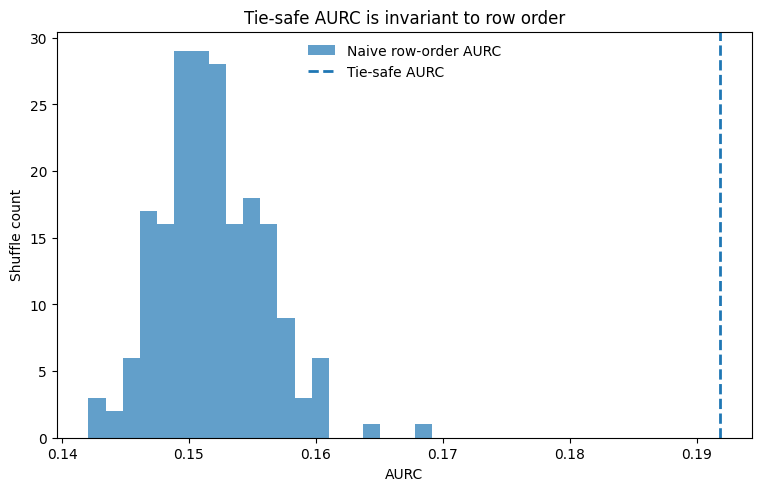

In [6]:
def hand_step_aurc(losses, confidence):



    losses = np.asarray(losses, float)

    confidence = np.asarray(confidence, float)

    total = len(losses)

    retained_loss, retained_n, previous_coverage, area = 0.0, 0, 0.0, 0.0

    for threshold in sorted(np.unique(confidence), reverse=True):

        group = confidence == threshold

        retained_loss += losses[group].sum()

        retained_n += int(group.sum())

        coverage = retained_n / total

        risk = retained_loss / retained_n

        area += risk * (coverage - previous_coverage)

        previous_coverage = coverage

    return area



tiny_cases = {

    "perfect_ranking": (np.array([0,0,1,1]), np.array([4,3,2,1])),

    "reversed_ranking": (np.array([1,1,0,0]), np.array([4,3,2,1])),

    "all_tied": (np.array([0,1,0,1]), np.ones(4)),

    "two_tie_groups": (np.array([0,1,0,1]), np.array([2,2,1,1])),

}

rows = []

for name, (losses, confidence) in tiny_cases.items():

    production = aurc(losses, confidence, tie_aware=True)

    reference = hand_step_aurc(losses, confidence)

    rows.append({"case":name, "production_aurc":production,

                 "hand_reference":reference, "absolute_difference":abs(production-reference)})

aurc_tests = pd.DataFrame(rows)



rng = np.random.default_rng(RANDOM_SEED)

tie_conf = rng.choice(np.array([0.9,0.6,0.3]), size=900, p=[0.3,0.4,0.3])

error_probability = np.select(

    [tie_conf==0.9, tie_conf==0.6, tie_conf==0.3],

    [0.05, 0.30, 0.60],

)

tie_loss = (rng.random(len(tie_conf)) < error_probability).astype(float)

shuffle_rows = []

for trial in range(200):

    index = np.random.default_rng(trial).permutation(len(tie_conf))

    shuffle_rows.append({

        "trial": trial,

        "naive_aurc": aurc(tie_loss[index], tie_conf[index], tie_aware=False),

        "tie_aware_aurc": aurc(tie_loss[index], tie_conf[index], tie_aware=True),

    })

shuffle_tests = pd.DataFrame(shuffle_rows)

aurc_tests.to_csv(TABLES / "N00_T03_aurc_reference_tests.csv", index=False)

shuffle_tests.to_csv(TABLES / "N00_T03b_aurc_tie_tests.csv", index=False)

display(aurc_tests.round(12))

print("Tie-aware spread:", shuffle_tests.tie_aware_aurc.max()-shuffle_tests.tie_aware_aurc.min())

print("Naive spread:", shuffle_tests.naive_aurc.max()-shuffle_tests.naive_aurc.min())



aurc_pass = (

    aurc_tests.absolute_difference.max() < 1e-12

    and (shuffle_tests.tie_aware_aurc.max()-shuffle_tests.tie_aware_aurc.min()) < 1e-12

    and (shuffle_tests.naive_aurc.max()-shuffle_tests.naive_aurc.min()) > 1e-4

)



fig, ax = plt.subplots(figsize=(7.5,4.8), constrained_layout=True)

ax.hist(shuffle_tests.naive_aurc, bins=20, alpha=0.7, label="Naive row-order AURC")

ax.axvline(shuffle_tests.tie_aware_aurc.iloc[0], linestyle="--", linewidth=2,

           label="Tie-safe AURC")

ax.set(title="Tie-safe AURC is invariant to row order", xlabel="AURC", ylabel="Shuffle count")

ax.legend(frameon=False)

fig.savefig(FIGURES/"N00_F01_tie_safe_aurc.png", dpi=300, bbox_inches="tight")

fig.savefig(FIGURES/"N00_F01_tie_safe_aurc.pdf", bbox_inches="tight")

plt.show()

## 6. Error-detection metrics

In [7]:
rng = np.random.default_rng(RANDOM_SEED+1)

n = 3000

errors = (rng.random(n) < 0.20).astype(int)

informative_score = np.clip(0.15 + 0.65*errors + rng.normal(0,0.18,n), 0, 1)

uninformative_score = rng.random(n)

rows = []

for name, score in {"informative":informative_score, "uninformative":uninformative_score}.items():

    rows.append({"score":name, "auroc":roc_auc_score(errors, score),

                 "auprc":average_precision_score(errors, score),

                 "error_prevalence":errors.mean()})

error_tests = pd.DataFrame(rows)

error_tests.to_csv(TABLES/"N00_T04_error_detection_tests.csv", index=False)

display(error_tests.round(4))

error_pass = (

    error_tests.loc[error_tests.score=="informative","auroc"].iloc[0] > 0.85

    and abs(error_tests.loc[error_tests.score=="uninformative","auroc"].iloc[0]-0.5) < 0.06

)

,score,auroc,auprc,error_prevalence
0,informative,0.9963,0.9874,0.2027
1,uninformative,0.5043,0.2047,0.2027


## 7. Calibration validation with probabilistically generated labels

,case,accuracy,mean_confidence,ece,nll,brier
0,calibrated,0.4646,0.4622,0.0055,1.3052,0.6664
1,overconfident,0.4646,0.7350,0.2704,1.7610,0.7755
2,underconfident,0.4646,0.3032,0.1614,1.4049,0.7121
3,biased,0.1333,0.4622,0.3289,2.1393,0.9994


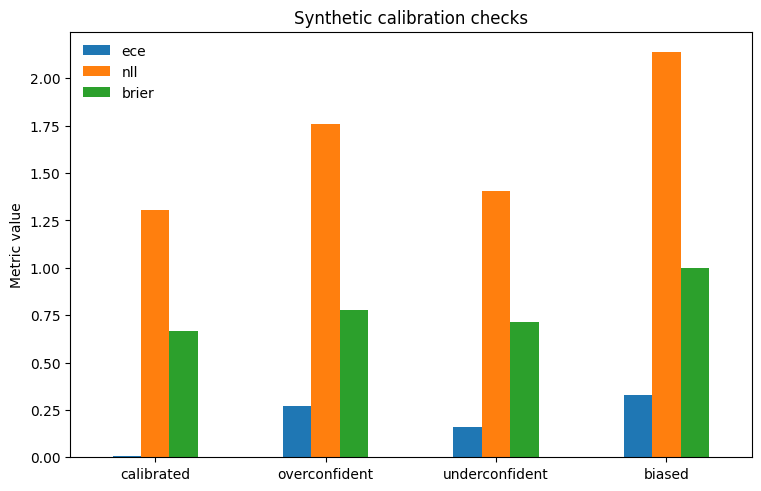

In [8]:
rng = np.random.default_rng(RANDOM_SEED+2)

n, k = 30000, 5

base_logits = rng.normal(size=(n,k))

base_logits -= base_logits.max(axis=1, keepdims=True)

calibrated_p = np.exp(base_logits)

calibrated_p /= calibrated_p.sum(axis=1, keepdims=True)

labels = np.array([rng.choice(k, p=row) for row in calibrated_p])



def temperature_transform(p, temperature):

    logp = np.log(np.clip(p, 1e-12, 1))

    z = logp / temperature

    z -= z.max(axis=1, keepdims=True)

    out = np.exp(z)

    return out / out.sum(axis=1, keepdims=True)



calibration_cases = {

    "calibrated": calibrated_p,

    "overconfident": temperature_transform(calibrated_p, 0.35),

    "underconfident": temperature_transform(calibrated_p, 2.5),

    "biased": np.roll(calibrated_p, shift=1, axis=1),

}

rows = []

for name, p in calibration_cases.items():

    rows.append({

        "case":name,

        "accuracy":accuracy_score(labels,p.argmax(axis=1)),

        "mean_confidence":p.max(axis=1).mean(),

        "ece":top_label_ece(labels,p,n_bins=15),

        "nll":log_loss(labels,p,labels=list(range(k))),

        "brier":multiclass_brier_score(labels,p,labels=list(range(k))),

    })

calibration_tests = pd.DataFrame(rows)

calibration_tests.to_csv(TABLES/"N00_T05_calibration_tests.csv", index=False)

display(calibration_tests.round(4))

cal_ece = calibration_tests.loc[calibration_tests.case=="calibrated","ece"].iloc[0]

cal_nll = calibration_tests.loc[calibration_tests.case=="calibrated","nll"].iloc[0]

cal_brier = calibration_tests.loc[calibration_tests.case=="calibrated","brier"].iloc[0]

calibration_pass = (

    cal_ece < 0.03

    and calibration_tests.loc[calibration_tests.case=="overconfident","ece"].iloc[0] > cal_ece

    and calibration_tests.loc[calibration_tests.case=="underconfident","ece"].iloc[0] > cal_ece

    and calibration_tests.loc[calibration_tests.case=="biased","nll"].iloc[0] > cal_nll

    and calibration_tests.loc[calibration_tests.case=="biased","brier"].iloc[0] > cal_brier

)



fig, ax = plt.subplots(figsize=(7.5,4.8), constrained_layout=True)

plot = calibration_tests.set_index("case")[["ece","nll","brier"]]

plot.plot(kind="bar", ax=ax)

ax.set(title="Synthetic calibration checks", xlabel="", ylabel="Metric value")

ax.tick_params(axis="x", rotation=0)

ax.legend(frameon=False)

fig.savefig(FIGURES/"N00_F02_calibration_validation.png", dpi=300, bbox_inches="tight")

fig.savefig(FIGURES/"N00_F02_calibration_validation.pdf", bbox_inches="tight")

plt.show()

## 8. Participant bootstrap validation

,simulations,empirical_coverage,coverage_mc_lower,coverage_mc_upper,mean_interval_width,grouping_preserved,reproducible
0,160,0.95,0.9039,0.9782,0.0736,True,True


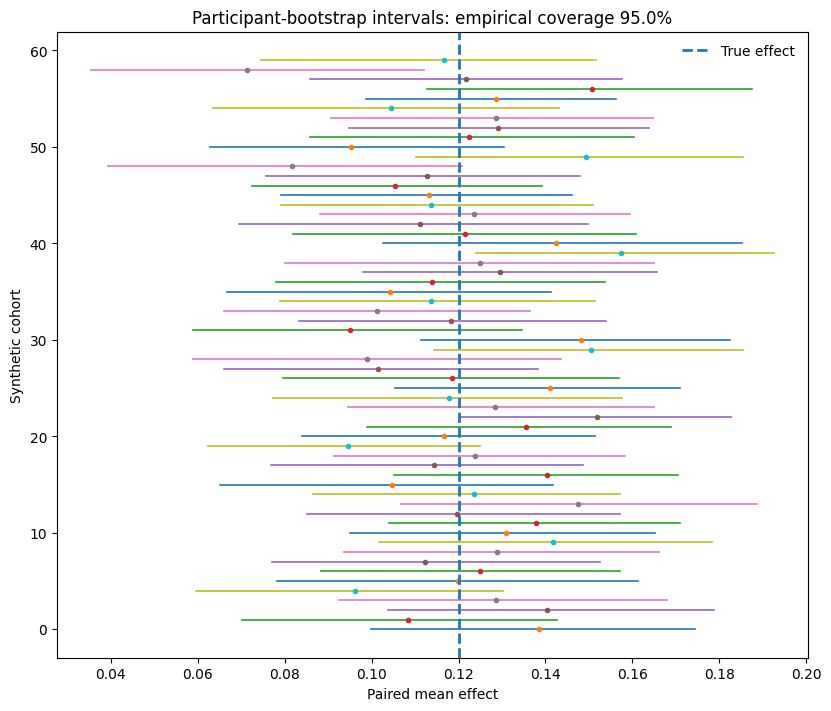

In [9]:
rng = np.random.default_rng(RANDOM_SEED+3)

n_simulations = 160

confidence_level = 0.95

true_effect = 0.12

simulation_rows = []

grouping_preserved = True

reproducible = True



for simulation in range(n_simulations):

    local_rng = np.random.default_rng(RANDOM_SEED + 1000 + simulation)

    n_participants = 120

    cluster_sizes = local_rng.choice([1,2], size=n_participants, p=[0.25,0.75])

    participant_ids = np.repeat(np.arange(n_participants), cluster_sizes)

    participant_effect = local_rng.normal(0,0.18,n_participants)

    row_effect = np.repeat(participant_effect, cluster_sizes)

    paired_difference = true_effect + row_effect + local_rng.normal(0,0.12,len(participant_ids))



    first_index = next(participant_bootstrap_indices(participant_ids,1,RANDOM_SEED+simulation))

    for participant in np.unique(participant_ids):

        selected_positions = np.flatnonzero(participant_ids[first_index] == participant)

        expected_size = np.sum(participant_ids == participant)

        if len(selected_positions) % expected_size != 0:

            grouping_preserved = False



    def statistic(index):

        return float(np.mean(paired_difference[index]))

    result = paired_participant_bootstrap(

        participant_ids, statistic, n_resamples=600,

        seed=RANDOM_SEED+simulation, confidence_level=confidence_level,

    )

    repeated = paired_participant_bootstrap(

        participant_ids, statistic, n_resamples=600,

        seed=RANDOM_SEED+simulation, confidence_level=confidence_level,

    )

    reproducible &= result["lower"] == repeated["lower"] and result["upper"] == repeated["upper"]

    simulation_rows.append({

        "simulation":simulation,

        "estimate":paired_difference.mean(),

        "lower":result["lower"],

        "upper":result["upper"],

        "covers_truth":result["lower"] <= true_effect <= result["upper"],

        "interval_width":result["upper"]-result["lower"],

    })



bootstrap_tests = pd.DataFrame(simulation_rows)

coverage = bootstrap_tests.covers_truth.mean()

coverage_ci = binomtest(

    int(bootstrap_tests.covers_truth.sum()), n_simulations

).proportion_ci(confidence_level=0.95, method="exact")

bootstrap_pass = (

    grouping_preserved and reproducible

    and coverage_ci.low <= confidence_level <= coverage_ci.high

    and bootstrap_tests.interval_width.mean() < 0.20

)

bootstrap_tests.to_csv(TABLES/"N00_T06_bootstrap_tests.csv", index=False)

display(pd.DataFrame([{

    "simulations":n_simulations, "empirical_coverage":coverage,

    "coverage_mc_lower":coverage_ci.low, "coverage_mc_upper":coverage_ci.high,

    "mean_interval_width":bootstrap_tests.interval_width.mean(),

    "grouping_preserved":grouping_preserved, "reproducible":reproducible,

}]).round(4))



fig, ax = plt.subplots(figsize=(8.2,7.0), constrained_layout=True)

shown = bootstrap_tests.iloc[:60].copy()

y = np.arange(len(shown))

for i, row in enumerate(shown.itertuples()):

    ax.plot([row.lower,row.upper],[i,i], linewidth=1.2)

    ax.plot(row.estimate,i,marker="o",markersize=3)

ax.axvline(true_effect, linestyle="--", linewidth=2, label="True effect")

ax.set(title=f"Participant-bootstrap intervals: empirical coverage {coverage:.1%}",

       xlabel="Paired mean effect", ylabel="Synthetic cohort")

ax.legend(frameon=False)

fig.savefig(FIGURES/"N00_F03_bootstrap_validation.png", dpi=300, bbox_inches="tight")

fig.savefig(FIGURES/"N00_F03_bootstrap_validation.pdf", bbox_inches="tight")

plt.show()

## 9. Freeze the final post-exploratory protocol

In [10]:
protocol = {

    "protocol_version":"N00_FINAL_V2_VALIDATED",

    "status":"post_exploratory_freeze",

    "frozen_utc":datetime.now(timezone.utc).isoformat(),

    "statement":(

        "This final protocol was frozen after earlier exploratory analyses. "

        "It is not described as a preregistration."

    ),

    "primary_model_metric":"quadratic_weighted_kappa",

    "primary_reliability_metric":"tie_aware_aurc",

    "secondary_metrics":[

        "accuracy","balanced_accuracy","macro_f1","weighted_f1","mae","mse",

        "within_one_accuracy","severe_error_rate","nll","multiclass_brier",

        "top_label_ece","error_auroc","error_auprc"

    ],

    "bootstrap_unit":"participant",

    "bootstrap_repetitions_final":2000,

    "confidence_level":0.95,

    "fixed_labels":[0,1,2,3,4],

    "top_label_ece_bins":15,

    "random_seed":RANDOM_SEED,

    "analysis_notes":[

        "Margins used later must be justified and frozen before the final comparison.",

        "Confirmation data are protected from training and model selection, not described as pristine."

    ],

}

protocol_path = CONFIGS/"measurement_protocol.json"

protocol_path.write_text(json.dumps(protocol,indent=2),encoding="utf-8")

display(pd.DataFrame([protocol]))

,protocol_version,status,frozen_utc,statement,primary_model_metric,primary_reliability_metric,secondary_metrics,bootstrap_unit,bootstrap_repetitions_final,confidence_level,fixed_labels,top_label_ece_bins,random_seed,analysis_notes
0,N00_FINAL_V2_VALIDATED,post_exploratory_freeze,2026-08-05T07:45:10.849722+00:00,This final protocol was frozen after earlier e...,quadratic_weighted_kappa,tie_aware_aurc,"[accuracy, balanced_accuracy, macro_f1, weight...",participant,2000,0.95,"[0, 1, 2, 3, 4]",15,20260800,[Margins used later must be justified and froz...


## 10. Acceptance certificate and exact output manifest

In [11]:
criteria = {

    "classification metrics match known cases":bool(classification_pass),

    "manual QWK matches sklearn":bool(qwk_pass),

    "AURC matches independent hand reference":bool(aurc_pass),

    "error detection behaves as expected":bool(error_pass),

    "calibration simulation is valid":bool(calibration_pass),

    "participant bootstrap passes coverage and grouping checks":bool(bootstrap_pass),

    "shared module exists":MODULE_PATH.exists(),

    "post-exploratory protocol exists":protocol_path.exists(),

}

criteria_frame = pd.DataFrame(

    [{"criterion":key,"passed":value} for key,value in criteria.items()]

)

criteria_path = TABLES/"N00_T07_acceptance_criteria.csv"

criteria_frame.to_csv(criteria_path,index=False)

display(criteria_frame)



accepted = all(criteria.values())

status = {

    "stage":"N00","protocol_version":protocol["protocol_version"],

    "accepted":accepted,"run_id":RUN_ID,

    "completed_utc":datetime.now(timezone.utc).isoformat(),

}

status_path = RESULTS/"n00_status.json"

status_path.write_text(json.dumps(status,indent=2),encoding="utf-8")



certificate_path = CERTIFICATES/"n00_certificate.txt"

certificate_lines = [

    "N00 MEASUREMENT VALIDATION CERTIFICATE",

    "="*48,

    *[f"{'PASS' if value else 'FAIL'}  {key}" for key,value in criteria.items()],

    "",

    f"Estimator accepted: {'YES' if accepted else 'NO'}",

    f"Protocol: {protocol['protocol_version']}",

    "Freeze status: post-exploratory final protocol",

]

certificate_path.write_text("\n".join(certificate_lines),encoding="utf-8")

print(certificate_path.read_text())



required_outputs = [

    MODULE_PATH, LOGS/"environment.csv",

    TABLES/"N00_T01_metric_tests.csv", TABLES/"N00_T02_qwk_tests.csv",

    TABLES/"N00_T03_aurc_reference_tests.csv", TABLES/"N00_T03b_aurc_tie_tests.csv",

    TABLES/"N00_T04_error_detection_tests.csv", TABLES/"N00_T05_calibration_tests.csv",

    TABLES/"N00_T06_bootstrap_tests.csv", criteria_path,

    FIGURES/"N00_F01_tie_safe_aurc.png", FIGURES/"N00_F01_tie_safe_aurc.pdf",

    FIGURES/"N00_F02_calibration_validation.png", FIGURES/"N00_F02_calibration_validation.pdf",

    FIGURES/"N00_F03_bootstrap_validation.png", FIGURES/"N00_F03_bootstrap_validation.pdf",

    protocol_path, status_path, certificate_path,

]



def sha256_file(path):

    digest = hashlib.sha256()

    with Path(path).open("rb") as handle:

        for block in iter(lambda:handle.read(1<<20),b""):

            digest.update(block)

    return digest.hexdigest()



missing = [str(path) for path in required_outputs if not Path(path).is_file()]

if missing:

    raise RuntimeError(f"Required N00 outputs are missing: {missing}")



manifest_rows = [{

    "run_id":RUN_ID,

    "producing_notebook":"N00_Measurement_Validation_FINAL_V2.ipynb",

    "protocol_version":protocol["protocol_version"],

    "path":str(Path(path).relative_to(FINAL_ROOT)),

    "size_bytes":Path(path).stat().st_size,

    "sha256":sha256_file(path),

    "created_utc":datetime.fromtimestamp(Path(path).stat().st_mtime,timezone.utc).isoformat(),

} for path in required_outputs]

manifest_path = MANIFESTS/"N00_output_manifest.csv"

pd.DataFrame(manifest_rows).to_csv(manifest_path,index=False)

print("Manifest:",manifest_path)



if not accepted:

    raise RuntimeError("N00 validation failed. Later notebooks must not run.")

print("N00 accepted. READY FOR N01.")

,criterion,passed
0,classification metrics match known cases,True
1,manual QWK matches sklearn,True
2,AURC matches independent hand reference,True
3,error detection behaves as expected,True
4,calibration simulation is valid,True
5,participant bootstrap passes coverage and grou...,True
6,shared module exists,True
7,post-exploratory protocol exists,True


N00 MEASUREMENT VALIDATION CERTIFICATE
PASS  classification metrics match known cases
PASS  manual QWK matches sklearn
PASS  AURC matches independent hand reference
PASS  error detection behaves as expected
PASS  calibration simulation is valid
PASS  participant bootstrap passes coverage and grouping checks
PASS  shared module exists
PASS  post-exploratory protocol exists

Estimator accepted: YES
Protocol: N00_FINAL_V2_VALIDATED
Freeze status: post-exploratory final protocol
Manifest: /content/drive/MyDrive/MasterThesis/Final Pipeline/manifests/N00_output_manifest.csv
N00 accepted. READY FOR N01.
